In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/ecb_aaa_spot_yield_curve.csv", parse_dates=["date"])

df.head()

,date,spot_3M,spot_1Y,spot_2Y,spot_5Y,spot_7Y,spot_10Y
0,2004-09-06,2.034172,2.298838,2.641262,3.457222,3.828505,4.209220
1,2004-09-07,2.040893,2.328891,2.679766,3.479518,3.839294,4.209626
2,2004-09-08,2.044384,2.346666,2.706542,3.507894,3.863753,4.228419
3,2004-09-09,2.037111,2.308988,2.646224,3.430628,3.789113,4.161872
4,2004-09-10,2.034645,2.271566,2.589654,3.374729,3.740559,4.120981


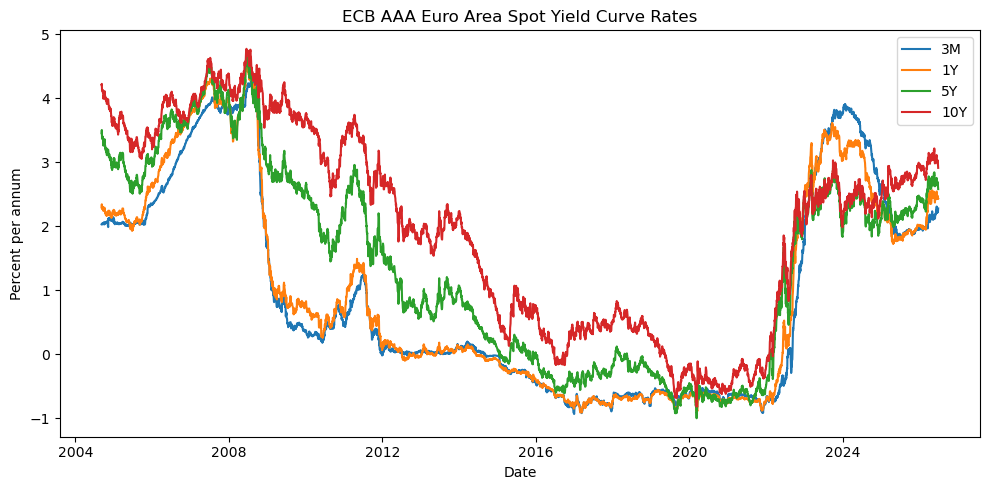

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["spot_3M"], label="3M")
plt.plot(df["date"], df["spot_1Y"], label="1Y")
plt.plot(df["date"], df["spot_5Y"], label="5Y")
plt.plot(df["date"], df["spot_10Y"], label="10Y")
plt.legend()
plt.title("ECB AAA Euro Area Spot Yield Curve Rates")
plt.xlabel("Date")
plt.ylabel("Percent per annum")
plt.tight_layout()
plt.show()

In [9]:
#ECB rates are in percent per annum, so we need to convert them to decimals:
rate_columns = [col for col in df.columns if col.startswith("spot_")]

df_decimal = df.copy()
df_decimal[rate_columns] = df_decimal[rate_columns] / 100.0

In [10]:
#For Vasicek calibration, let's start with the 3M rate:
vasicek_data = df_decimal[["date", "spot_3M"]].dropna().copy()
vasicek_data = vasicek_data.rename(columns={"spot_3M": "short_rate"})

vasicek_data.to_csv(PROCESSED_DIR / "vasicek_short_rate_data.csv", index=False)